# 03 Baseline IDS

Train and evaluate a centralized PyTorch MLP using the processed CIC-IDS2017 arrays from Phase 2.

d:\FedGuard-XAI\src\model.py:72: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  torch.from_numpy(features_array),


Training rows: 200,000
Evaluation rows: 50,000
Accuracy:  0.9344
Precision: 0.9762
Recall:    0.8706
F1-score:  0.9204
Confusion matrix [[TN, FP], [FN, TP]]:
[[27741   462]
 [ 2820 18977]]


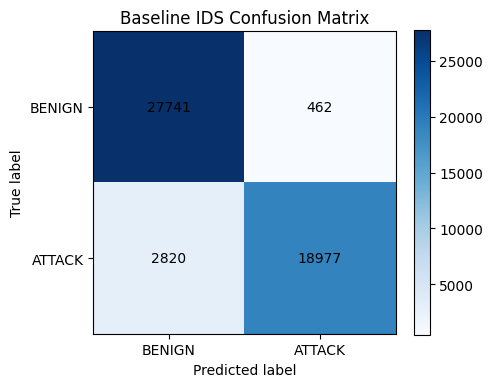

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "data" / "processed").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np

from src.model import create_mlp_model, evaluate

processed_dir = project_root / "data" / "processed"

x_train = np.load(processed_dir / "x_train.npy", mmap_mode="r")
y_train = np.load(processed_dir / "y_train.npy", mmap_mode="r")
x_validation = np.load(processed_dir / "x_validation.npy", mmap_mode="r")
y_validation = np.load(processed_dir / "y_validation.npy", mmap_mode="r")

# Keep the first baseline run practical on CPU; later experiments can use all rows.
train_limit = min(len(x_train), 200_000)
evaluation_limit = min(len(x_validation), 50_000)

model = create_mlp_model(
    hidden_size=128,
    epochs=3,
    batch_size=4096,
    learning_rate=1e-3,
    seed=42,
)
model.fit(x_train[:train_limit], y_train[:train_limit])
metrics = evaluate(
    model,
    x_validation[:evaluation_limit],
    y_validation[:evaluation_limit],
)

print(f"Training rows: {train_limit:,}")
print(f"Evaluation rows: {evaluation_limit:,}")
print(f"Accuracy:  {metrics.accuracy:.4f}")
print(f"Precision: {metrics.precision:.4f}")
print(f"Recall:    {metrics.recall:.4f}")
print(f"F1-score:  {metrics.f1:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(metrics.confusion_matrix)

plt.figure(figsize=(5, 4))
plt.imshow(metrics.confusion_matrix, cmap="Blues")
plt.title("Baseline IDS Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["BENIGN", "ATTACK"])
plt.yticks([0, 1], ["BENIGN", "ATTACK"])
for row in range(2):
    for column in range(2):
        plt.text(column, row, metrics.confusion_matrix[row, column], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()